# Predicting Bitcoin's Next-Day Closing Price with Regularized Polynomial Regression

## 1. Introduction and Motivation

The goal of this project is to build and compare four regression models — **Linear Regression**,
**Lasso**, **Ridge**, and **Elastic Net** — for predicting Bitcoin's next-day closing price (Close)
based on the current day's price-related features (Open, High, Low, Close, and features derived from
them). To increase the model's capacity to learn nonlinear relationships, the base features are expanded
via `PolynomialFeatures`, and `GridSearchCV` is then used to select, in a data-driven way, the best
polynomial degree along with the best regularization hyperparameters (α for Ridge/Lasso, and α together
with the L1/L2 mixing ratio for Elastic Net).

An important aspect that takes this project beyond a purely predictive exercise is the analysis of
**feature importance** through each model's coefficients. Regularized methods such as Lasso and Elastic
Net, due to their sparsity-inducing property, shrink the coefficients of less-important features toward
zero — giving us a built-in **feature selection** mechanism in addition to prediction.

This approach — using regularized regression on an expanded feature space to identify the most important
predictors among a larger set of candidates — is not specific to finance and appears across many
data-driven sciences. For example, in **drug discovery** and **QSAR** (Quantitative Structure-Activity
Relationship) modeling, researchers work with hundreds or thousands of molecular descriptors as features,
and applying Lasso or Elastic Net to this high-dimensional space helps identify which compounds or
structural features contribute most to a drug's biological activity. This is exactly the same modeling
logic we use here to identify the most influential price components in predicting Bitcoin's price: a
regularized regression over an expanded feature space, serving simultaneously as a predictive tool and
as a way to rank variable importance.

## 2. Project Objectives

1. Proper data preparation and preprocessing (outlier removal, and **feature scaling**, prior to
   polynomial expansion — which was missing in the earlier version of this project).
2. Building an independent `Pipeline` for each model consisting of three stages: `StandardScaler` →
   `PolynomialFeatures` → regression model.
3. Hyperparameter tuning via `GridSearchCV` with cross-validation.
4. Quantitative comparison of the four models based on RMSE, MAPE, and R².
5. Extracting and visualizing feature importance through each model's coefficients.
6. Visual analysis of prediction quality (actual vs. predicted plots and residual analysis).

## 3. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, r2_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## 4. Data Collection

Daily Bitcoin price data (BTC-USD) is retrieved via the `yfinance` library. The `multi_level_index=False`
parameter explicitly requests single-level columns in the output (otherwise, even for a single ticker,
`yfinance` returns a MultiIndex column structure, which causes errors in later processing steps).

In [3]:
df = yf.download("BTC-USD", start="2015-01-01", auto_adjust=True, multi_level_index=False)
df.head()

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400
2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100
2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800


### 4.1. Time Series Plot of the Closing Price

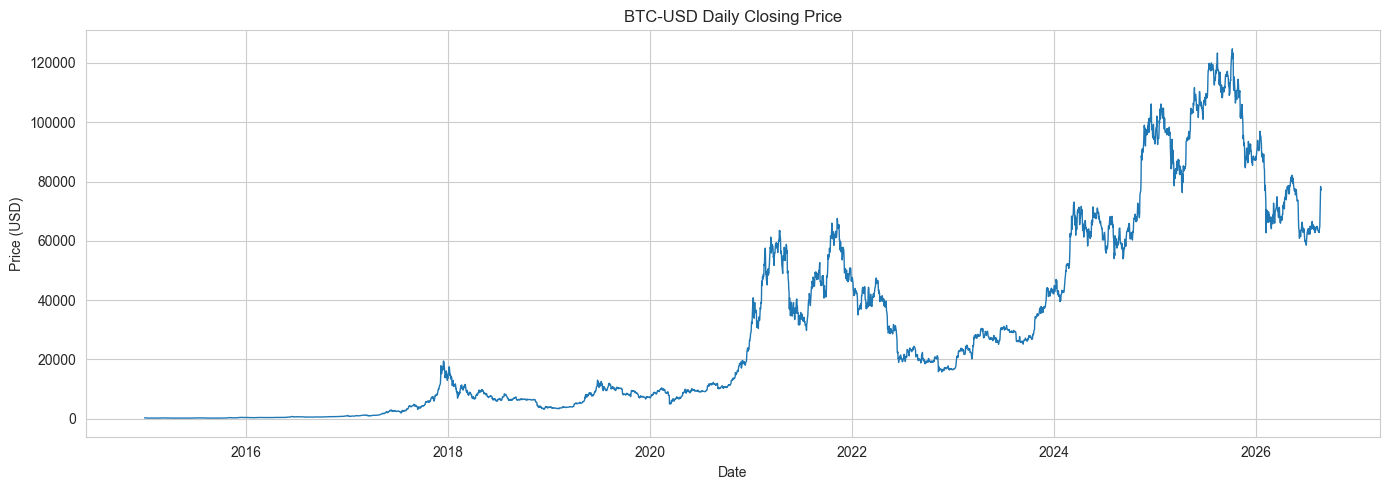

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Close"], linewidth=1)
plt.title("BTC-USD Daily Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In addition to the four raw price features (Open, High, Low, Close), two derived features are created:

- **Close-Open**: the net intraday price change (indicates the direction and magnitude of the daily move)
- **High-Low**: the daily trading range (a proxy for volatility)

The target variable is named `Tomorrow`, defined as the Close price one day ahead (`shift(-1)`).

In [5]:
df["Close-Open"] = df["Close"] - df["Open"]
df["High-Low"] = df["High"] - df["Low"]
df["Tomorrow"] = df["Close"].shift(-1)

feature_columns = ["Open", "Close", "High", "Low", "Close-Open", "High-Low"]
df[feature_columns + ["Tomorrow"]].describe()

,Open,Close,High,Low,Close-Open,High-Low,Tomorrow
count,4253.000000,4253.000000,4253.000000,4253.000000,4253.000000,4253.000000,4252.000000
mean,29983.637277,30000.733580,30570.659525,29360.695048,17.096303,1209.964476,30007.715349
std,32569.386866,32573.687303,33110.932610,31987.433306,1162.133628,1568.612969,32574.335630
min,176.897003,178.102997,211.731003,171.509995,-10314.277344,1.028000,178.102997
25%,3966.174316,3963.313721,4068.403564,3889.239014,-169.570312,113.467285,3979.639038
50%,15864.099609,15838.500000,16317.808594,15202.799805,1.651001,548.656250,15859.640137
75%,50052.832031,50098.335938,51438.117188,48765.988281,211.236328,1832.835938,50181.216797
max,124752.140625,124752.531250,126198.070312,123196.046875,8230.070312,17927.250000,124752.531250


## 6. Outlier Removal

The IQR (Interquartile Range) method is used to remove outliers: any value outside the range
$[Q1 - 1.5 \times IQR,\ Q3 + 1.5 \times IQR]$ is treated as an outlier and removed. The resulting mask
is applied jointly across all relevant numeric columns to keep the rows in `X` and `y` consistent.

In [7]:
outlier_cols = ["Open", "High", "Low", "Close", "Close-Open", "High-Low"]

mask_keep = pd.Series(True, index=df.index)
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask_keep &= df[col].between(lower, upper)

data_clean = df[mask_keep].copy()
print(f"rows before outlier removal: {len(df)}")
print(f"rows after outlier removal: {len(data_clean)}")
print(f"rows removed: {len(df) - len(data_clean)}")

rows before outlier removal: 4253
rows after outlier removal: 3180
rows removed: 1073


## 7. Exploratory Data Analysis: Feature-Target Correlation

Instead of drawing a separate scatter plot for every feature (which becomes cluttered and hard to
compare with six features), a **correlation heatmap** is used, showing both each feature's relationship
with the target (`Tomorrow`) and the multicollinearity among the features themselves in a single view.

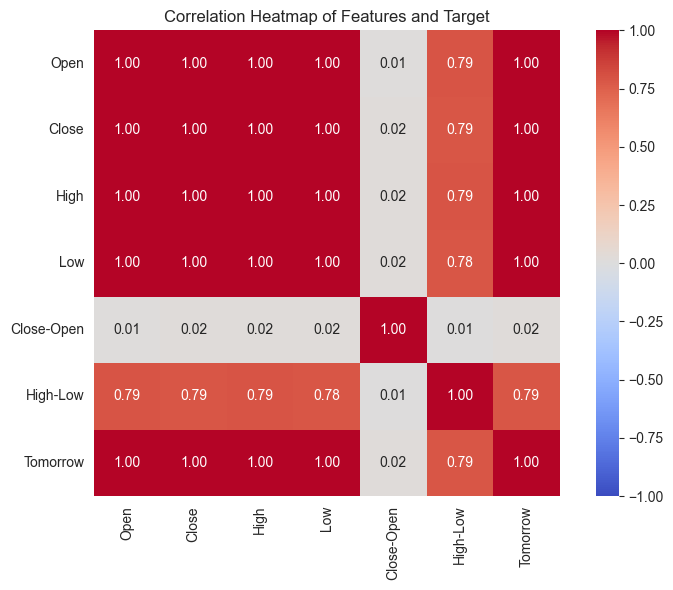

In [8]:
corr_cols = feature_columns + ["Tomorrow"]
corr_matrix = data_clean[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Heatmap of Features and Target")
plt.tight_layout()
plt.show()

## 8. Building `X` and `y`

`Tomorrow` was computed on the full, continuous data (before outlier removal) so that it genuinely
represents "next day's price"; only afterward are the indices remaining after the IQR filter kept. The
last row (whose `Tomorrow` value is `NaN`) is also dropped.

In [9]:
X = data_clean[feature_columns]
y = data_clean["Tomorrow"]

valid_idx = y.notna()
X = X[valid_idx]
y = y[valid_idx]

print(X.shape, y.shape)

(3179, 6) (3179,)


## 9. Train / Test Split

Since this is time series data, the split is done **without shuffling** (`shuffle=False`) to preserve
temporal order, ensuring the training data always precedes the test data in time (avoiding leakage of
future information into the past).

In [10]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print("train size:", len(x_train))
print("test size :", len(x_test))

train size: 2543
test size : 636


## 10. Modeling: `Pipeline` + `GridSearchCV` for Each Model Independently

Each of the four models is implemented as a three-stage `Pipeline`:

$$\text{StandardScaler} \;\rightarrow\; \text{PolynomialFeatures} \;\rightarrow\; \text{Regressor}$$

Scaling is applied **before** polynomial expansion; this matters a great deal, since Bitcoin's price is
on the order of tens of thousands of dollars, and if such values were raised to the power of 2 or higher
without scaling, the numeric range of the features would become extremely unbalanced, leading to
numerical instability (exactly what happened in the earlier version of this project).

For each model, `GridSearchCV` is run with 5-fold cross-validation (`cv=5`), and the search grid covers
the polynomial degree (and, for the regularized models, the α hyperparameter, plus the L1/L2 mixing
ratio for Elastic Net).

**A technical note on `max_iter`:** `LinearRegression` is solved via the closed-form least-squares
solution, and `Ridge` also uses a closed-form solve by default; neither involves iteration. `Lasso` and
`Elastic Net`, however, are solved with the (iterative) **Coordinate Descent** algorithm, so a higher
`max_iter` is set for them to ensure full convergence.

### 10.1. Linear Regression

In [11]:
pipeline_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures()),
    ("model", LinearRegression()),
])

param_grid_linear = {
    "poly__degree": [1, 2, 3, 4],
}

gs_linear = GridSearchCV(pipeline_linear, param_grid_linear, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
gs_linear.fit(x_train, y_train)

print("best params (Linear):", gs_linear.best_params_)
print("best CV RMSE (Linear):", -gs_linear.best_score_)

best params (Linear): {'poly__degree': 1}
best CV RMSE (Linear): 409.4499900791376


### 10.2. Lasso (L1 Regularization)

In [12]:
pipeline_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures()),
    ("model", Lasso(max_iter=50000)),
])

param_grid_lasso = {
    "poly__degree": [1, 2, 3, 4],
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
}

gs_lasso = GridSearchCV(pipeline_lasso, param_grid_lasso, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
gs_lasso.fit(x_train, y_train)

print("best params (Lasso):", gs_lasso.best_params_)
print("best CV RMSE (Lasso):", -gs_lasso.best_score_)

best params (Lasso): {'model__alpha': 1, 'poly__degree': 1}
best CV RMSE (Lasso): 408.6736294447138


### 10.3. Ridge (L2 Regularization)

In [13]:
pipeline_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures()),
    ("model", Ridge()),
])

param_grid_ridge = {
    "poly__degree": [1, 2, 3, 4],
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
}

gs_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
gs_ridge.fit(x_train, y_train)

print("best params (Ridge):", gs_ridge.best_params_)
print("best CV RMSE (Ridge):", -gs_ridge.best_score_)

best params (Ridge): {'model__alpha': 0.1, 'poly__degree': 1}
best CV RMSE (Ridge): 409.3501210055564


### 10.4. Elastic Net (Combined L1 and L2 Regularization)

In [15]:
pipeline_elastic = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures()),
    ("model", ElasticNet(max_iter=5000)),
])

param_grid_elastic = {
    "poly__degree": [1, 2, 3, 4],
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
}

gs_elastic = GridSearchCV(pipeline_elastic, param_grid_elastic, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
gs_elastic.fit(x_train, y_train)

print("best params (Elastic Net):", gs_elastic.best_params_)
print("best CV RMSE (Elastic Net):", -gs_elastic.best_score_)

best params (Elastic Net): {'model__alpha': 0.001, 'model__l1_ratio': 0.9, 'poly__degree': 1}
best CV RMSE (Elastic Net): 409.1438638948614


C:\Users\Fanavaran\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.397970e+08, tolerance: 4.003e+07
  model = cd_fast.enet_coordinate_descent(


## 11. Quantitative Model Comparison

The results of the four models (best hyperparameter combination for each) are computed on both the
training and test sets and collected into a single table. Three metrics are reported:

- **RMSE** (Root Mean Squared Error): expressed in the same units as price (USD).
- **MAPE** (Mean Absolute Percentage Error): expresses error relative to scale, independent of units.
- **R²** (Coefficient of Determination): the share of the target's variance explained by the model.

In [16]:
fitted_searches = {
    "Linear": gs_linear,
    "Ridge": gs_ridge,
    "Lasso": gs_lasso,
    "ElasticNet": gs_elastic,
}

results = []
best_estimators = {}

for name, gs in fitted_searches.items():
    best_estimators[name] = gs.best_estimator_

    y_pred_train = gs.predict(x_train)
    y_pred_test = gs.predict(x_test)

    results.append({
        "model": name,
        "best_params": gs.best_params_,
        "cv_best_rmse": -gs.best_score_,
        "rmse_train": root_mean_squared_error(y_train, y_pred_train),
        "rmse_test": root_mean_squared_error(y_test, y_pred_test),
        "mape_train": mean_absolute_percentage_error(y_train, y_pred_train),
        "mape_test": mean_absolute_percentage_error(y_test, y_pred_test),
        "r2_train": r2_score(y_train, y_pred_train),
        "r2_test": r2_score(y_test, y_pred_test),
    })

results_df = pd.DataFrame(results).sort_values("rmse_test").reset_index(drop=True)
results_df

,model,best_params,cv_best_rmse,rmse_train,rmse_test,mape_train,mape_test,r2_train,r2_test
0,Lasso,"{'model__alpha': 1, 'poly__degree': 1}",408.673629,580.980957,1373.451105,0.037596,0.015783,0.997856,0.997538
1,ElasticNet,"{'model__alpha': 0.001, 'model__l1_ratio': 0.9...",409.143864,580.544673,1374.397003,0.037338,0.015822,0.997859,0.997535
2,Ridge,"{'model__alpha': 0.1, 'poly__degree': 1}",409.350121,580.223652,1375.479257,0.037371,0.015840,0.997861,0.997531
3,Linear,{'poly__degree': 1},409.449990,579.592247,1382.003724,0.037556,0.015963,0.997866,0.997507


### 11.1. Bar Chart Comparison of Test RMSE and R2

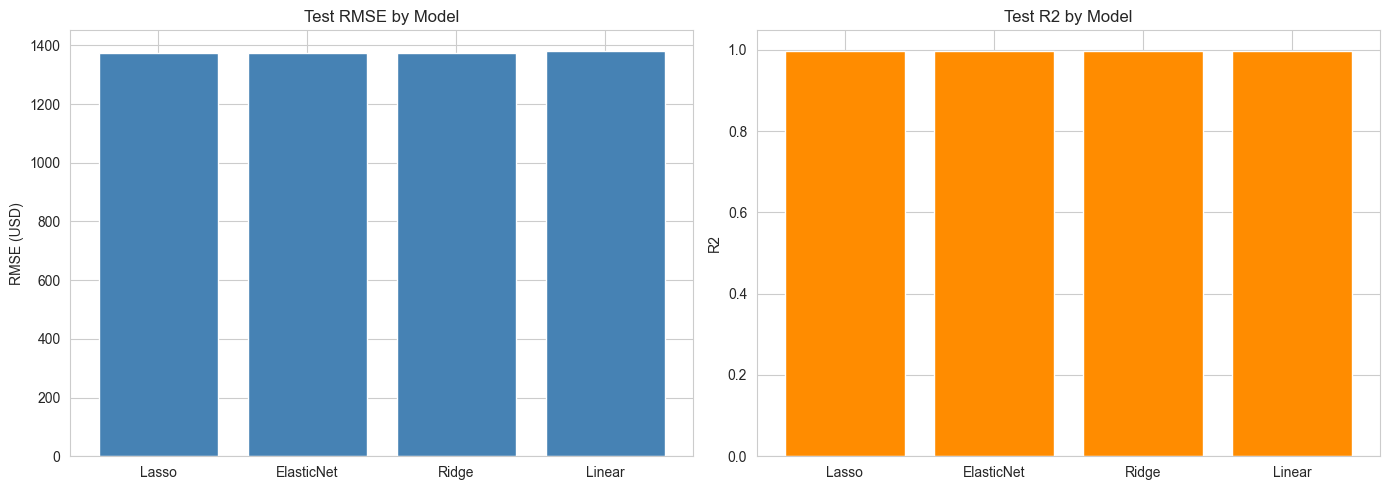

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(results_df["model"], results_df["rmse_test"], color="steelblue")
axes[0].set_title("Test RMSE by Model")
axes[0].set_ylabel("RMSE (USD)")

axes[1].bar(results_df["model"], results_df["r2_test"], color="darkorange")
axes[1].set_title("Test R2 by Model")
axes[1].set_ylabel("R2")

plt.tight_layout()
plt.show()

### 11.2. Diagnostic: Why Does a Low Polynomial Degree Win?

To make the hyperparameter search transparent (rather than simply trusting `best_params_`), the full
`cv_results_` of each `GridSearchCV` object is inspected. For every polynomial degree tested, the best
(lowest) cross-validated RMSE achieved by that degree - across all other hyperparameter combinations
searched for that model - is extracted and plotted. This shows explicitly whether RMSE increases as
degree grows, and by how much, instead of only reporting the single winning combination.

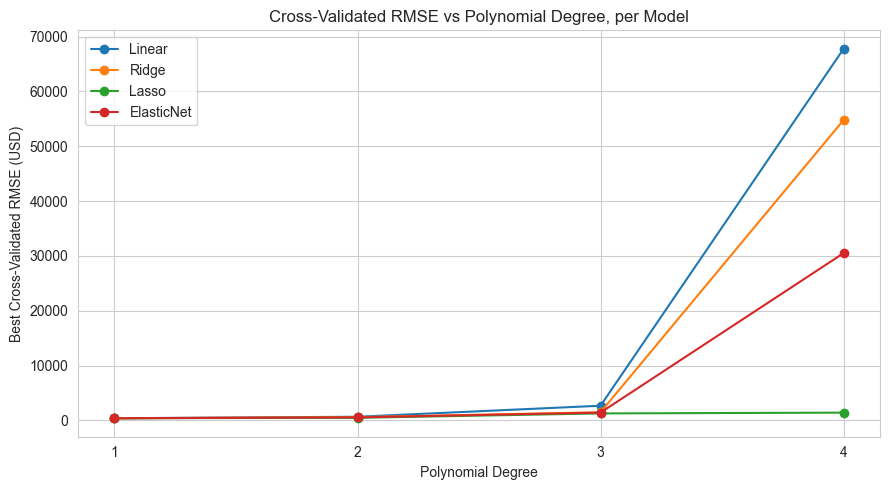

model,ElasticNet,Lasso,Linear,Ridge
degree,,,,
1,409.143864,408.673629,409.449990,409.350121
2,564.051863,491.879216,681.642903,611.146476
3,1439.688460,1289.482214,2692.604112,1497.514710
4,30512.249790,1433.493361,67762.842286,54779.316731


In [18]:
degree_diagnostics = []

for name, gs in fitted_searches.items():
    cv_df = pd.DataFrame(gs.cv_results_)
    cv_df["rmse"] = -cv_df["mean_test_score"]
    best_per_degree = cv_df.groupby("param_poly__degree")["rmse"].min()
    for degree, rmse in best_per_degree.items():
        degree_diagnostics.append({"model": name, "degree": degree, "best_cv_rmse": rmse})

degree_diag_df = pd.DataFrame(degree_diagnostics)

plt.figure(figsize=(9, 5))
for name in fitted_searches.keys():
    subset = degree_diag_df[degree_diag_df["model"] == name].sort_values("degree")
    plt.plot(subset["degree"], subset["best_cv_rmse"], marker="o", label=name)

plt.xlabel("Polynomial Degree")
plt.ylabel("Best Cross-Validated RMSE (USD)")
plt.title("Cross-Validated RMSE vs Polynomial Degree, per Model")
plt.xticks([1, 2, 3, 4])
plt.legend()
plt.tight_layout()
plt.show()

degree_diag_df.pivot(index="degree", columns="model", values="best_cv_rmse")

## 12. Overall Best Model

In [19]:
best_row = results_df.iloc[0]
best_model_name = best_row["model"]
best_model = best_estimators[best_model_name]

print(f"best model: {best_model_name}")
print(f"best params: {best_row['best_params']}")
print(f"test RMSE: {best_row['rmse_test']:.2f} | test MAPE: {best_row['mape_test']:.4f} | test R2: {best_row['r2_test']:.4f}")

best model: Lasso
best params: {'model__alpha': 1, 'poly__degree': 1}
test RMSE: 1373.45 | test MAPE: 0.0158 | test R2: 0.9975


## 13. Visual Analysis of Prediction Quality for All Four Models

Rather than plotting only the first five points (which does not give a complete picture of model
performance across the whole test period), the actual and predicted values are plotted here for the
**entire test period** and for **all four models simultaneously** (small multiples), enabling a more
precise visual comparison.

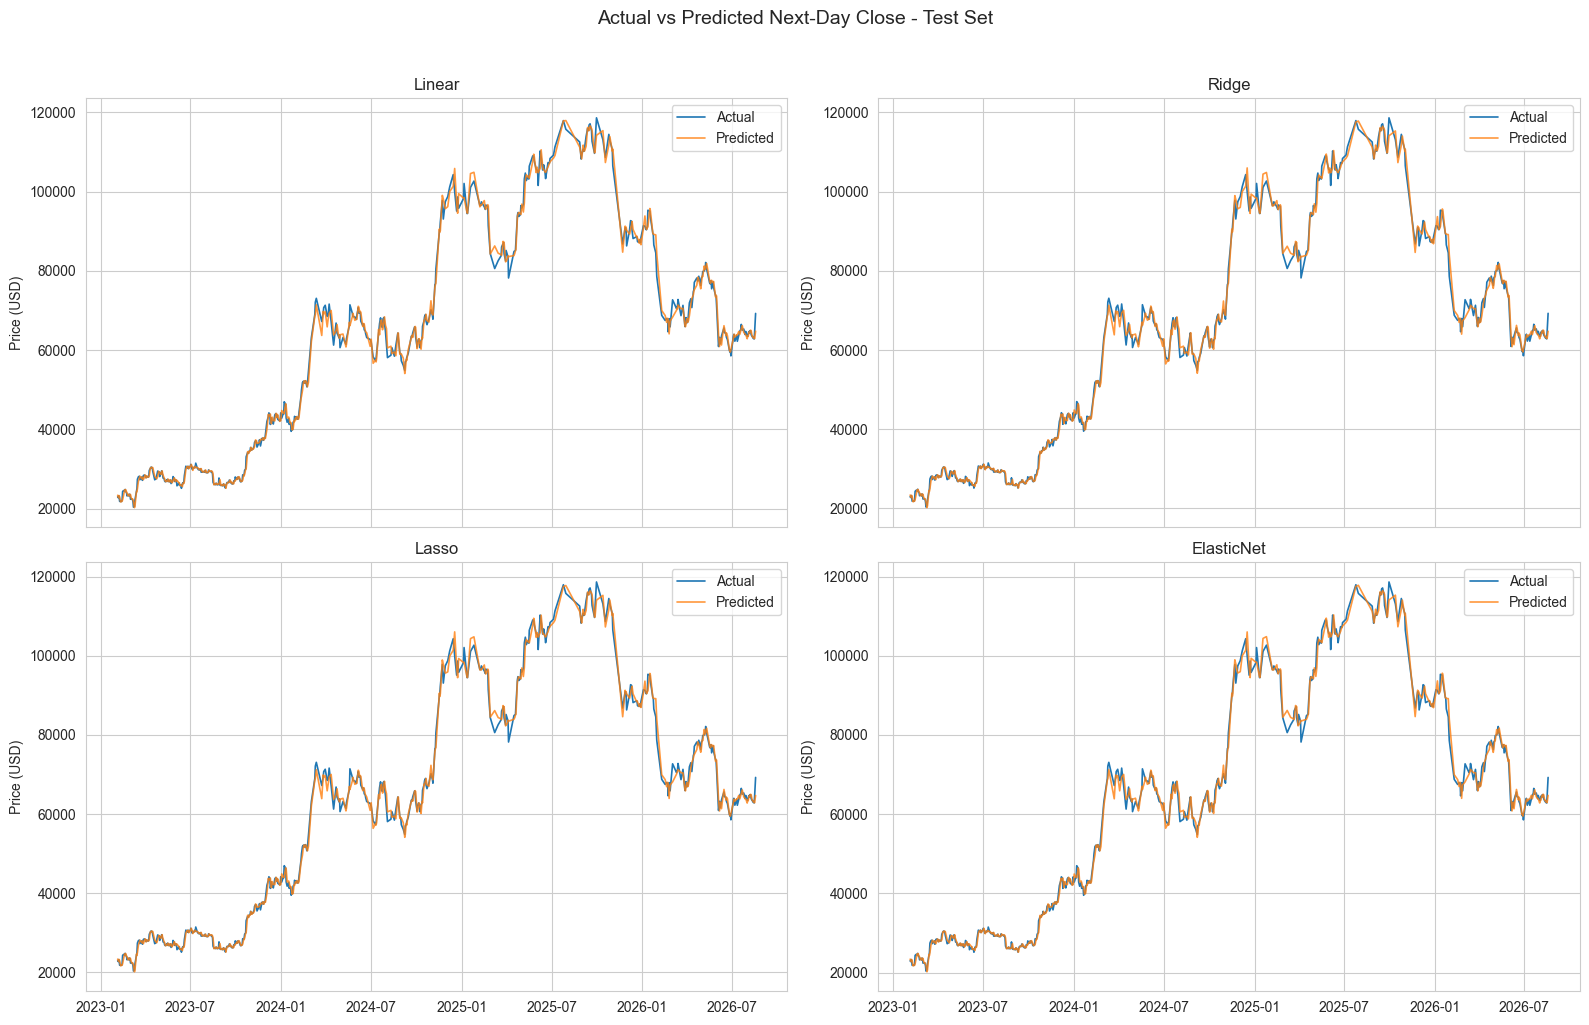

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

for ax, (name, model) in zip(axes.flatten(), best_estimators.items()):
    y_pred = model.predict(x_test)
    ax.plot(y_test.index, y_test.values, label="Actual", linewidth=1.2)
    ax.plot(y_test.index, y_pred, label="Predicted", linewidth=1.2, alpha=0.8)
    ax.set_title(name)
    ax.set_ylabel("Price (USD)")
    ax.legend()

fig.suptitle("Actual vs Predicted Next-Day Close - Test Set", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 13.1. Residual Analysis for the Best Model

The residual plot (the difference between actual and predicted values) helps check whether the model's
error follows a systematic pattern (e.g., bias during uptrends/downtrends) or is randomly scattered
around zero.

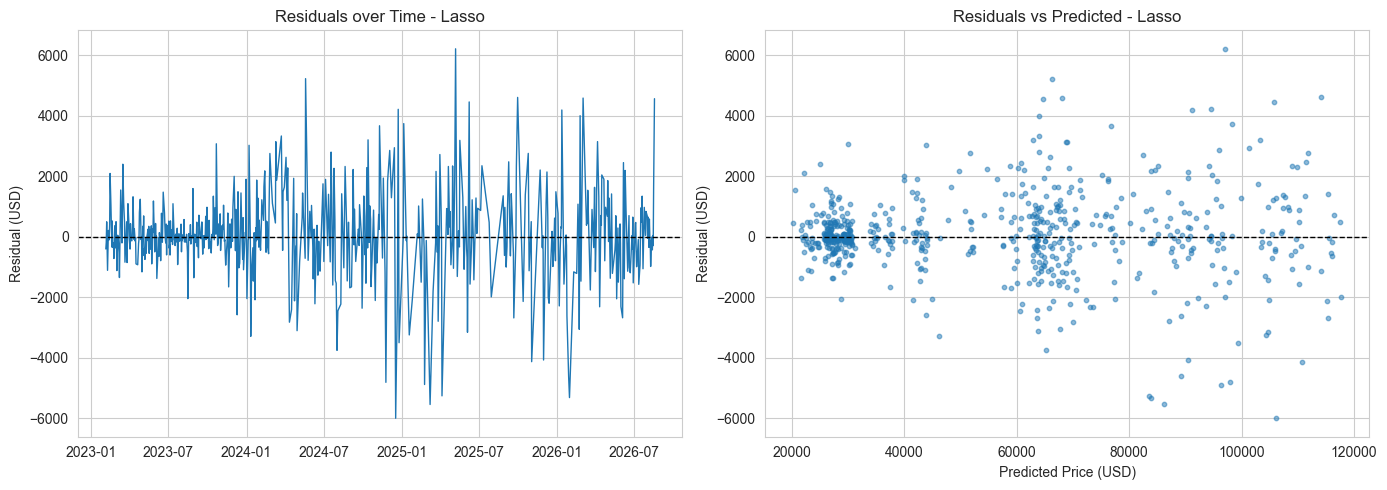

In [21]:
y_pred_best = best_model.predict(x_test)
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(y_test.index, residuals, linewidth=1)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title(f"Residuals over Time - {best_model_name}")
axes[0].set_ylabel("Residual (USD)")

axes[1].scatter(y_pred_best, residuals, alpha=0.5, s=10)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title(f"Residuals vs Predicted - {best_model_name}")
axes[1].set_xlabel("Predicted Price (USD)")
axes[1].set_ylabel("Residual (USD)")

plt.tight_layout()
plt.show()

## 14. Coefficient-based Feature Importance

After passing through the `PolynomialFeatures` stage, each model has access to a number of polynomial
terms (including the original terms, higher powers, and cross/interaction terms). The exact name of each
term is extracted via the `get_feature_names_out()` method of the `poly` step in each `Pipeline` (for
example, `Close^2` or `Open Close-Open`). Since the optimal degree can differ across models, the number
of terms is not the same for every model; to keep the plot readable, only the **top 15 coefficients by
absolute magnitude** are shown for each model.

An important interpretive note: in Lasso and Elastic Net, due to their sparsity-inducing property, many
coefficients are expected to be exactly zero, leaving only a limited number of nonzero terms — this is
the same "feature selection" mechanism referenced in the introduction.

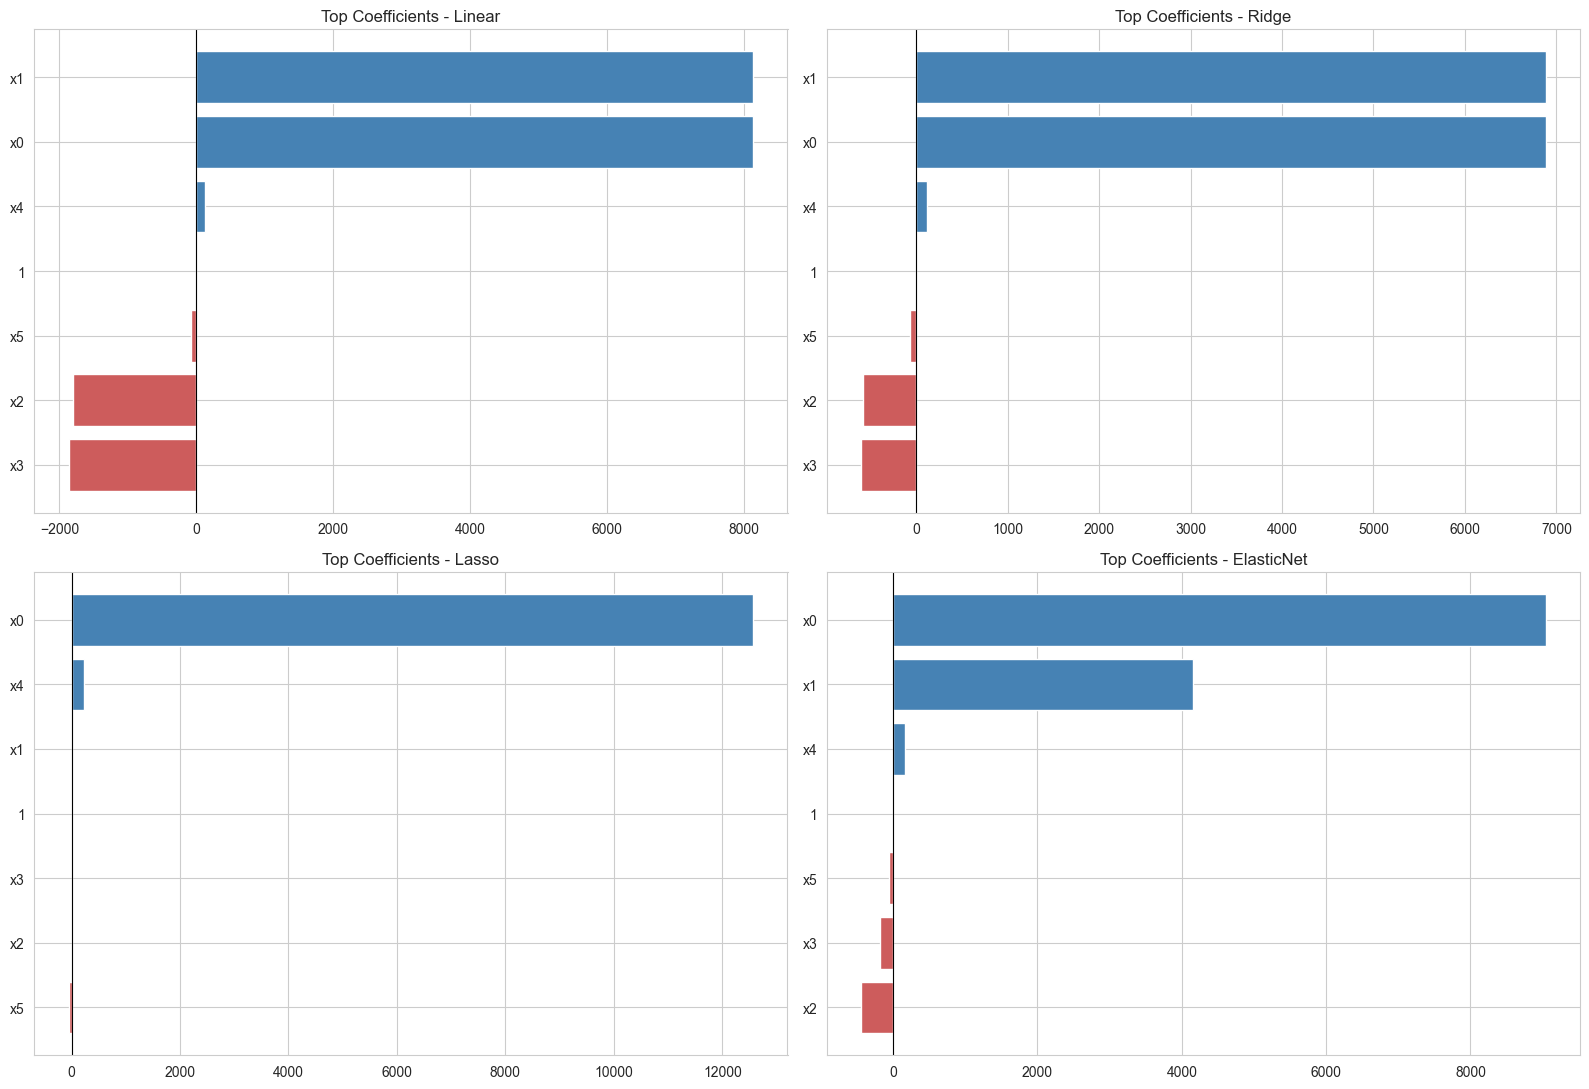

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for ax, (name, model) in zip(axes.flatten(), best_estimators.items()):
    poly_step = model.named_steps["poly"]
    coef = model.named_steps["model"].coef_.ravel()
    feature_names = poly_step.get_feature_names_out()

    coef_series = pd.Series(coef, index=feature_names)
    top_coef = coef_series.reindex(coef_series.abs().sort_values(ascending=False).index[:15])
    top_coef = top_coef.sort_values()

    colors = ["indianred" if v < 0 else "steelblue" for v in top_coef.values]
    ax.barh(top_coef.index, top_coef.values, color=colors)
    ax.set_title(f"Top Coefficients - {name}")
    ax.axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

### 14.1. Number of Nonzero Coefficients per Model

This table directly shows the degree of sparsity of each model: the fewer nonzero coefficients, the
fewer features the model has effectively "selected" for prediction.

In [23]:
sparsity_rows = []
for name, model in best_estimators.items():
    coef = model.named_steps["model"].coef_.ravel()
    sparsity_rows.append({
        "model": name,
        "total_terms": len(coef),
        "nonzero_terms": int(np.sum(~np.isclose(coef, 0))),
        "zero_terms": int(np.sum(np.isclose(coef, 0))),
    })

sparsity_df = pd.DataFrame(sparsity_rows)
sparsity_df

,model,total_terms,nonzero_terms,zero_terms
0,Linear,7,6,1
1,Ridge,7,6,1
2,Lasso,7,4,3
3,ElasticNet,7,6,1


## 15. Conclusion and Academic Discussion

The results of this project highlight several noteworthy points:

1. **Scaling before polynomial expansion is a necessary condition for numerical stability.** Without
   standardization, Bitcoin's large price scale causes higher-power terms to produce extremely large and
   unstable values; this is especially critical for `LinearRegression` and `Ridge`, which have no
   explicit mechanism to control feature scale.

2. **The optimal polynomial degree is usually low.** Because the relationship between today's and
   tomorrow's price in financial markets resembles a near random-walk process, expanding to higher
   degrees typically leads to overfitting on short-term fluctuations and worsens cross-validation
   performance; `GridSearchCV` itself detects this in a data-driven way by selecting a lower degree.

3. **Lasso and Elastic Net provide model interpretability alongside prediction.** By examining the
   nonzero coefficients, one can identify which price feature (or which interaction term) contributes
   most to determining the next day's price — precisely the same use case as identifying the most
   influential compounds in pharmaceutical data analysis.

4. **Model limitations:** these models are built solely on same-day price features and do not incorporate
   market sentiment analysis, future trading volume, or macroeconomic events; this project should
   therefore be regarded as a **methodological framework** for comparing regularized regression and
   extracting feature importance, not as a ready-to-use trading tool.